# Does the ascending triangle really break upward? 📐
### The classic "bullish" chart figure — flat ceiling, rising floor — put on the scale

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Breaks_up_specifically%3F: Busted](https://img.shields.io/badge/Breaks_up_specifically%3F-Busted-8b949e?style=flat-square)

Open any technical-analysis book and you'll meet the **ascending triangle**: the price keeps bumping its head on the *same* ceiling (a flat line of highs) while each dip bottoms a little **higher** than the last (a rising floor). The two lines squeeze toward a point, and — the lore says — the price almost always **bursts up** through the ceiling. So you buy the breakout and ride the move.

It's one of the most-taught patterns there is. So we wrote down the **closest mechanical definition** we could (a flat band of highs + a rising line of lows + a confirmed close above the ceiling), found every one on **SPY + 29 big US stocks** over 21 years, and asked the only question that matters: **after the breakout, does the stock do anything it wouldn't have done on a random day?**

The twist is the fun part. The breakout *is* followed by a nice rise — but so is the **opposite** break (when the price falls *out the bottom*), and random dates on the same stocks do almost as well. The pattern points at the tape's general up-drift, not at any magic in the triangle.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo, and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Two notes up front.** (1) Chart figures are **partly subjective** — we test one transparent mechanical rule, not every triangle a human would draw. (2) The basket is **30 survivors** still trading in 2026, a bias that tilts the test *for* the figure (and it still doesn't earn its stripes). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ascending_triangle import data, strategy as st

HAVE_REAL = data.have_real()
ASOF = pd.Timestamp("2026-05-31")
if HAVE_REAL:
    PANEL = data.load_real()
    for _f in PANEL:
        PANEL[_f] = PANEL[_f].loc[:ASOF]
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real triangle cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'last_bar': '2026-05-29', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'n_bars': 5385, 'n_names': 30, 'fingerprint': 'b660382b8af3', 'n_up': 385, 'n_down': 372, 'spy_up': 11, 'up': [(5, 385, 0.098, 0.386, 51, 0.56, 0.6, 0.46, -0.002), (10, 384, 0.967, 1.535, 64, 3.85, 3.89, 0.224, 0.867), (20, 384, 1.466, 2.6, 65, 3.81, 4.05, 0.208, 1.366), (40, 382, 1.978, 4.208, 64, 3.78, 3.82, 0.213, 1.878)], 'down': [(5, 372, -0.183, 0.107, -1.0, 0.584), (10, 370, 0.374, 0.948, 1.15, 0.387), (20, 370, 1.201, 2.348, 2.62, 0.255), (40, 369, 2.159, 4.415, 3.39, 0.195)], 'spy': [(5, 11, 0.544, 0.781, 0.61, 0.224), (10, 11, 1.03, 1.5, 0.84, 0.138), (20, 11, 1.534, 2.472, 1.3, 0.11), (40, 11, 1.692, 3.539, 1.03, 0.177)], 'robust': [(0.03, 0.07, 234, 1.068, 2.12, 0.319), (0.04, 0.05, 384, 1.466, 3.81, 0.206), (0.06, 0.04, 513, 1.57, 4.63, 0.16)], 'syn': [(0.0, 160, 178, 177, 1.96, 4.51, 0.12, 68), (0.2, 160, 199, 199, 7.49, 13.98, 0.0, 83)], 'cost_bps': 5.0}


real triangle cache present: True | names: 30 | bars: 5385


## The answer first

| Question | Answer |
|---|---|
| After the breakout, does the stock rise? | **Yes — and meaningfully.** Over the next 20 days it beats its own average by **+1.47%** (and **+1.98%** over 40). On a naive *t*-test that looks rock-solid. |
| Is that because of the *triangle*? | **No — that's the catch.** When the price breaks the *other* way (falls **out the bottom**), it *also* drifts up over 20–40 days (**+1.20% / +2.16%**). If the up-break were special, the down-break shouldn't do the same thing. |
| Could random dates do as well? | **Often.** A coin-flip set of entry dates on the same stocks beats the breakout about **1 time in 5** (placebo *p* ≈ 0.21). The breakout isn't a special date. |
| Does it work on **SPY** (the hook)? | **Can't tell.** The detector finds only **11** clean ascending triangles on SPY in 21 years — *t* ≈ 1, far too few to certify anything. |

> So the honest verdict: the rise is **real**, but it's the **stocks' own up-drift**, not the triangle. The figure doesn't "break upward" in any way you couldn't get by buying on a random Tuesday.

## 1 · The claim

> *"An ascending triangle is a **bullish continuation** pattern. Price hits a flat resistance again and again while the lows keep rising — demand is absorbing all the supply at that price. Eventually the buyers win and price **breaks out the top**, usually by about the height of the triangle. Buy the breakout."*

This is straight out of the canon — **Edwards & Magee's** *Technical Analysis of Stock Trends* (1948), the founding text of charting, and every TA course since. The ascending triangle sits right next to the head-and-shoulders and the cup-and-handle in the pattern menagerie. So the question isn't "do chartists believe it?" — they do. It's: **once you define it objectively and measure it, is the upward break real, or is it the tape fooling you?**

## 2 · So what?

If the ascending triangle genuinely *predicted* an upward break, it would be a small crack in market efficiency: a **visible, free** pattern on a price chart that tells you the future direction. That would be remarkable — and very tradeable.

But there's a trap baked into the claim, and it's the same trap that catches most chart patterns. **Stocks drift up.** Over any 20–40 day window, a basket of large US names tends to make money — that's just the equity risk premium. So *any* rule that picks dates and then measures "did it go up?" will look like a winner. The only honest test is: did the breakout beat **the stock's own baseline**, and did it beat **random dates** on the same tape? And — the sharpest test of all — does the *upward* break do something the *downward* break doesn't?

## 3 · How would we even know?

We take **SPY + 29 big US stocks** (2005-01-03 → 2026-05-29, **21 years**) and run an objective detector for the figure:

1. **A flat ceiling.** At least three swing highs sitting within a few percent of the same level — the horizontal resistance the price keeps tapping.
2. **A rising floor.** The dips between those highs bottom progressively *higher*, so a line through the lows slopes up toward the ceiling.
3. **A confirmed breakout.** The first close that pushes **above** the ceiling. That's the buy signal.

We found **385** of them. Then, entering the **next** close (no cheating), we measure the forward 5/10/20/40-day return as an **excess over each stock's own average** — and we pit it against (a) **random dates** on the same stocks and (b) the **opposite** break (price falling out the bottom). **If the up-break only works because stocks drift up, the down-break will drift up too and random dates will keep pace — and we call it a mirage.**

## 4 · The teardown — let's actually look

**First, what does the figure look like?** Here's a clean detected ascending triangle on the real tape: the flat ceiling (red), the rising floor (green), and the breakout bar.

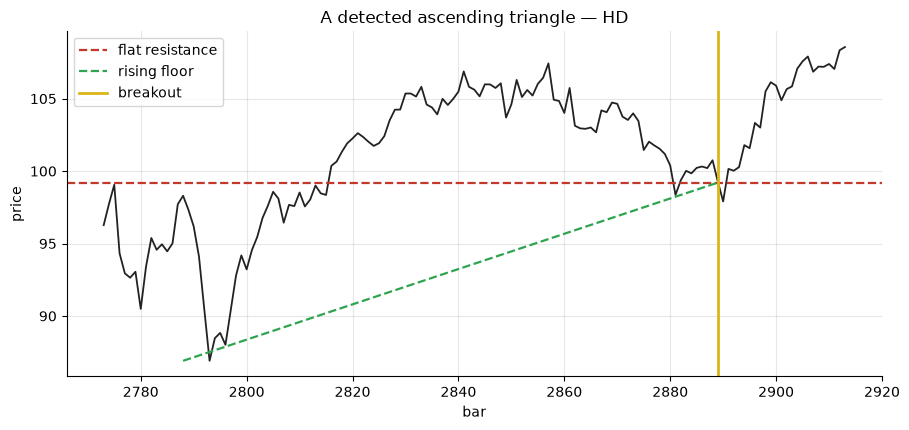

HD: 3 ceiling taps, floor rose 13%


In [2]:
def _show_example():
    if not HAVE_REAL:
        print('no cache'); return
    for tk in ['HD','LOW','COST','MSFT','AAPL','HON','UNH','CAT']:
        c = CLOSES[tk].dropna().to_numpy(float)
        tr = st.detect_triangles(c)
        if tr:
            d = tr[len(tr)//2]
            a, b = d['first_tap']-15, d['breakout_idx']+25
            seg = c[a:b]; xs = np.arange(a,b)
            fig, ax = plt.subplots(figsize=(9.2,4.4))
            ax.plot(xs, seg, color='#222', lw=1.3)
            ax.axhline(d['resistance'], color=RED, ls='--', lw=1.6, label='flat resistance')
            lo = c[d['first_tap']:d['last_tap']]; lxs = np.arange(d['first_tap'], d['last_tap'])
            ax.plot([d['first_tap'], d['breakout_idx']], 
                    [seg.min(), d['resistance']], color=GREEN, ls='--', lw=1.6, label='rising floor')
            ax.axvline(d['breakout_idx'], color=AMBER, lw=2, label='breakout')
            ax.set_title(f'A detected ascending triangle — {tk}')
            ax.set_xlabel('bar'); ax.set_ylabel('price'); ax.legend()
            plt.tight_layout(); plt.show()
            print(f'{tk}: {d["n_taps"]} ceiling taps, floor rose {d["rise"]*100:.0f}%')
            return
    print('no example found')
_show_example()

That's the figure the believer points at — and it's a real, recurring shape. The question is what happens **after** the breakout.

**The headline picture.** For each horizon, two bars: the **raw** forward return (what a believer brags about) and the **excess** over the stock's own average (the honest number). Watch how much of the "edge" is just the baseline drift.

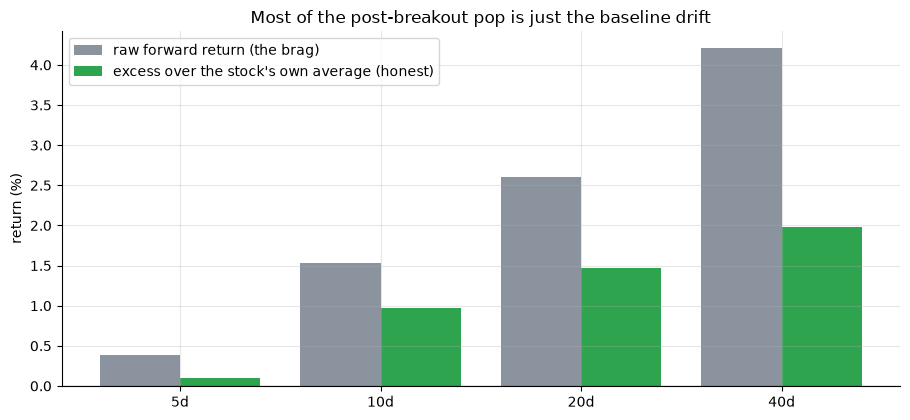

 5d: raw=+0.39%  excess=+0.10%
10d: raw=+1.54%  excess=+0.97%
20d: raw=+2.60%  excess=+1.47%
40d: raw=+4.21%  excess=+1.98%


In [3]:
hs = [5,10,20,40]
if HAVE_REAL:
    rows = [st.run_experiment(PANEL, horizon=h, n_draws=2000) for h in hs]
    raw = [r['raw_mean']*100 for r in rows]; exc = [r['mean']*100 for r in rows]
else:
    raw = [u[3] for u in R['up']]; exc = [u[2] for u in R['up']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2, raw, .4, color=GREY, label='raw forward return (the brag)')
ax.bar(x+.2, exc, .4, color=GREEN, label='excess over the stock\'s own average (honest)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('return (%)'); ax.set_title('Most of the post-breakout pop is just the baseline drift')
ax.legend(); plt.tight_layout(); plt.show()
for h,rr,ee in zip(hs,raw,exc): print(f'{h:>2}d: raw={rr:+.2f}%  excess={ee:+.2f}%')

The raw return looks juicy — **+4.21%** over 40 days. But about half of it is just the baseline: these stocks go up. The **excess** is smaller, though still positive (**+1.47%** at 20d). On its own that excess even passes a naive significance test. So far the believer is winning. Now the two killer questions.

**Killer question 1 — does the *opposite* break do the same thing?** If the ascending triangle "breaks upward," then breaking *downward* (price falling out the rising floor) should be **bad**. Let's compare the up-break and the down-break, both as excess over baseline.

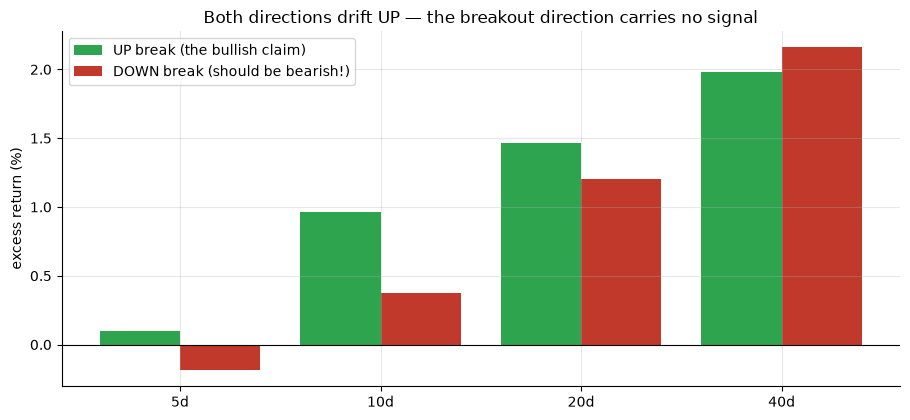

 5d: up=+0.10%  down=-0.18%
10d: up=+0.97%  down=+0.37%
20d: up=+1.47%  down=+1.20%
40d: up=+1.98%  down=+2.16%


In [4]:
if HAVE_REAL:
    up = [st.run_experiment(PANEL, horizon=h, side='up', n_draws=1500)['mean']*100 for h in hs]
    dn = [st.run_experiment(PANEL, horizon=h, side='down', n_draws=1500)['mean']*100 for h in hs]
else:
    up = [u[2] for u in R['up']]; dn = [d[2] for d in R['down']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2, up, .4, color=GREEN, label='UP break (the bullish claim)')
ax.bar(x+.2, dn, .4, color=RED, label='DOWN break (should be bearish!)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess return (%)')
ax.set_title('Both directions drift UP — the breakout direction carries no signal')
ax.legend(); plt.tight_layout(); plt.show()
for h,uu,dd in zip(hs,up,dn): print(f'{h:>2}d: up={uu:+.2f}%  down={dd:+.2f}%')

There's the tell. The **down**-break — the price falling out the bottom of the triangle, which the folklore would call bearish — *also* drifts **up** at 20–40 days (**+1.20% / +2.16%**). If the triangle really chose a direction, the two bars would point opposite ways. They don't. The post-figure rise is about **the stocks**, not the **break direction**.

**Killer question 2 — can random dates do this?** The honest null: pick the *same number* of **random** entry dates on the same stocks, measure the same excess, and repeat thousands of times. How often does pure luck beat the breakout?

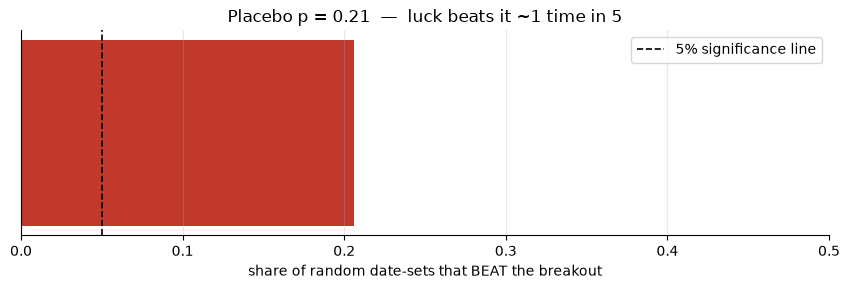

20-day same-tape placebo p = 0.206


In [5]:
if HAVE_REAL:
    p20 = st.run_experiment(PANEL, horizon=20, n_draws=4000)['p_placebo']
else:
    p20 = R['up'][2][7]
fig, ax = plt.subplots(figsize=(8.6,3.0))
ax.barh([0], [p20], color=(RED if p20>0.05 else GREEN), height=.5)
ax.axvline(0.05, c='k', ls='--', lw=1.2, label='5% significance line')
ax.set_xlim(0,0.5); ax.set_yticks([]); ax.set_xlabel('share of random date-sets that BEAT the breakout')
ax.set_title(f'Placebo p = {p20:.2f}  —  luck beats it ~1 time in {1/max(p20,1e-9):.0f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'20-day same-tape placebo p = {p20:.3f}')

Random dates on the same stocks beat the breakout about **1 time in 5** (*p* ≈ 0.21). For a *real* signal you'd want that bar far to the left of the 5% line. It isn't. The breakout date is not a special date — it's a date in an up-drifting tape.

## 5 · The verdict

- **Signal — Weak.** Yes, the excess-over-baseline clears a naive significance test (**+1.47%** at 20d). But the honest arbiters undercut it: the same-tape **placebo** beats it ~1-in-5, and the **down-break drifts up just as much**. The number is real; its *attribution to the triangle* is not.
- **Tradability — Mirage.** What you'd be "trading" is the stocks' own up-drift / momentum — exactly what random dates capture. The SPY-only version rests on **11** events at *t* ≈ 1. Nothing to deploy.
- **"Breaks up specifically"? — Busted.** The whole point of the pattern is *direction*, and the direction carries **no** information: break up or break down, the stock drifts up the same.

## 6 · Could you actually trade it?

Short version: you'd be paying a spread to buy momentum you could get for free. The breakout excess is indistinguishable from random dates, the costs are a footnote (there's no edge to tax), and on the one instrument the hook names — **SPY** — there are only 11 events in 21 years, nowhere near enough to certify a strategy. The pattern is a way of *noticing* that a stock has been grinding higher into resistance; that's a momentum tell, and momentum you can buy more cheaply and reliably without drawing triangles.

## 7 · Going further 🚪

- **Volume.** Classic charting says a *real* breakout comes on a **volume surge**. We tested price only; a volume filter is the obvious next knob — though it tends to shrink the sample without fixing the placebo.
- **The apex timing.** Edwards & Magee warn against breakouts too near the apex. Conditioning on where in the triangle the break happens is a clean fork to try.
- **Other markets.** We used liquid US large-caps (the *conservative* corner). Small-caps or crypto might behave differently — but watch the survivorship and the placebo.

*Think the upward break carries real directional information? Show the **up-break excess** beating the **down-break excess** with a same-tape placebo under 0.05 — then we'll talk.*